# Multi-Goal Financial Asset Recommender System

**RL-Driven Transformer Pipeline:**
- **[PHASE 1 — Member A] Autoencoder Embeddings**: Trains a masked weighted autoencoder on ALL historical data with exponential time-decay weighting. Produces compressed 8-dimensional behavioral embeddings per asset.
- **[PHASE 2–3 — Member D] RL Transformer + Gaussian Policy**: A Transformer processes the entire market universe via Self-Attention. A Gaussian Policy head outputs (μ, σ) per asset — target allocation and exploration noise.
- **[PHASE 4–5 — Member D + C] Simulator Environment + REINFORCE**: Sampled weights are passed into the non-differentiable simulator. An inverse-exponential reward is returned. The Policy Gradient theorem updates the Transformer without needing gradients through the simulator.

### Architecture
All function definitions live in worker modules (`_*.py`). This notebook is a **thin orchestration layer** — edit `_constants.py` for config, dive into workers for implementation details.

In [1]:
%pip install yfinance matplotlib seaborn scipy lxml html5lib requests tqdm nbformat joblib
# Install CUDA-enabled PyTorch for GPU acceleration
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

from IPython.display import display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
%matplotlib inline

Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cu121
Note: you may need to restart the kernel to use updated packages.


## Phase 1 — Member A: Data Scraping & Autoencoder Embeddings

In [2]:
# ── Configure Pipeline ──
from _constants import DEFAULT_PIPELINE_CONFIG, DataSyncMode
config = DEFAULT_PIPELINE_CONFIG.copy()
config["data_source_mode"] = DataSyncMode.OFFLINE_CSV_ONLY  # Override for this run

# ── Fetch Universe & Build Dataset ──
from _data_worker import fetch_macro_universe, generate_dataset_member_a, run_data_diagnostics

tickers = fetch_macro_universe() if config["data_source_mode"] != DataSyncMode.OFFLINE_CSV_ONLY else []
master_df, price_matrix, volume_matrix, daily_returns, drip_returns = generate_dataset_member_a(tickers, config)

# ── Validate Data Quality ──
run_data_diagnostics(master_df, config)

[11:17:11] [Member A] Booting in mode [OFFLINE_CSV_ONLY]

[11:17:15] [Member A] Preprocessing Configured ML Features...
   -> WARNING: Requested config feature 'sector' not found in master_df.
   -> WARNING: Requested config feature 'industry' not found in master_df.
   -> WARNING: Requested config feature 'state' not found in master_df.
   -> WARNING: Requested config feature 'quoteType' not found in master_df.
   -> WARNING: Requested config feature 'exchange' not found in master_df.

=== DATAFRAME DIAGNOSTICS & SYSTEM MAPPING ===
Total Equities Tracked: 6544
Total Columns Processed per Asset: 414

All Features Extracted in Master DF:
['longBusinessSummary', 'companyOfficers', 'executiveTeam', 'maxAge', 'priceHint', 'previousClose', 'open', 'dayLow', 'dayHigh', 'regularMarketPreviousClose', 'regularMarketOpen', 'regularMarketDayLow', 'regularMarketDayHigh', 'trailingPE', 'volume', 'regularMarketVolume', 'averageVolume', 'averageVolume10days', 'averageDailyVolume10Day', 'bid', 'ask', 

In [3]:
# ── Phase 1 Persistence Orchestration ──
from _ml_worker import train_pytorch_embedding_model, save_embedding_cache, load_embedding_cache

# 1. Try to load from disk first using config settings
DATA_CACHE = load_embedding_cache(
    master_df, price_matrix, volume_matrix, daily_returns, 
    config, drip_daily_returns=drip_returns, folder=config["ml_cache_dir"]
)

# 2. Train only if cache is missing or force-retrain is ON
if DATA_CACHE is None or config["ml_force_retrain"]:
    print(f"[{time.strftime('%H:%M:%S')}] No valid cache found. Starting training...")
    DATA_CACHE = train_pytorch_embedding_model(
        master_df, price_matrix, volume_matrix, daily_returns,
        config, drip_daily_returns=drip_returns
    )
    save_embedding_cache(DATA_CACHE, folder=config["ml_cache_dir"])
else:
    print(f"[{time.strftime('%H:%M:%S')}] SUCCESS: Loaded pre-trained embeddings from '{config['ml_cache_dir']}/'")

# 3. Generate Walk-Forward Snapshots if enabled (or force rebuild is ON)
from _ml_worker import generate_walkforward_embeddings_monthly
if config.get("wf_enabled", False) or config.get("wf_force_rebuild", False):
    print(f"[{time.strftime('%H:%M:%S')}] Checking/Building Walk-Forward Cache...")
    generate_walkforward_embeddings_monthly(DATA_CACHE["model_checkpoint"], ticker_data, config, None, None, start_year=config.get("wf_start_year", 2000), force_rebuild=config.get("wf_force_rebuild", False))


[11:17:18] [Member A] Persistence: Found existing model for architecture ed8_dm64_lr001. Loading...
[11:17:18] SUCCESS: Loaded pre-trained embeddings from 'cache/'


## Phases 2–5 — Member D: End-to-End RL Transformer Portfolio Optimizer

**Replaces the old Member B/C scoring pipeline** with an End-to-End Reinforcement Learning system.

In [ ]:
# ── Universal Policy RL Training (Member D) ──
import importlib
import _rl_worker, _sim_worker, _constants
importlib.reload(_constants)
importlib.reload(_sim_worker)
importlib.reload(_rl_worker)
from _rl_worker import train_rl_agent
from _constants import TEST_PROFILES
import pandas as pd
from IPython.display import display

print(f"Loaded {len(TEST_PROFILES)} User Profiles for Universal Training")
print(f"Drawdown Risk Range: {min(p['drawdown_sensitivity'] for p in TEST_PROFILES)} - {max(p['drawdown_sensitivity'] for p in TEST_PROFILES)}")
print(f"Volatility Risk Range: {min(p['volatility_sensitivity'] for p in TEST_PROFILES)} - {max(p['volatility_sensitivity'] for p in TEST_PROFILES)}")
print(f"Capital Range: ${min(p['start_cap'] for p in TEST_PROFILES):,.0f} - ${max(p['start_cap'] for p in TEST_PROFILES):,.0f}")

# Run the Universal Policy training (agent randomly samples from ALL profiles internally)
# user_profile here is just used for the FINAL greedy evaluation output
rl_results = train_rl_agent(DATA_CACHE, TEST_PROFILES[0], config, verbose=True)

final_portfolio = rl_results.get('portfolio_weights', {})
history = rl_results.get('training_history', [])

print(f"\n{'=' * 60}")
print(f"  UNIVERSAL AGENT TRAINING COMPLETE")
print(f"  Selected Assets: {len(final_portfolio)}")
print(f"{'=' * 60}")

if final_portfolio:
    print(f"\n  {'Ticker':<10} {'Weight':<10}")
    print(f"  {'-'*25}")
    for ticker, weight in sorted(final_portfolio.items(), key=lambda x: x[1], reverse=True)[:20]:
        print(f"  {ticker:<10} {weight:<10.2%}")

# Plot reward convergence
if history:
    rewards = [h['reward'] for h in history]
    plt.figure(figsize=(12, 4))
    plt.plot(rewards, alpha=0.3, label='Per-Episode')
    # Rolling average
    window = min(20, len(rewards))
    if window > 1:
        rolling = pd.Series(rewards).rolling(window).mean()
        plt.plot(rolling, linewidth=2, label=f'Rolling {window}-ep Mean')
    plt.xlabel('Episode')
    plt.ylabel('Reward')
    plt.title('Universal Policy RL Agent — Reward Convergence')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


Loaded 30 User Profiles for Universal Training
Risk Range: 1.0 - 9.0
Capital Range: $2,500 - $2,000,000
[11:17:36] [Member D] STANDARD UNIVERSAL training | 30 profiles | 10000000 episodes
[11:17:36] [Member C] Building Annual Simulation Cache...
[11:17:57] [Member C] Cache built for 136 paths x 30 years x 6601 assets.
  [SIMULATOR] Cyclic Mode: LOOP | Starts: 136 | Horizon: 4y

  [Episode     1] Reward:  38.828 | Profile: Down Payment Safety
    -> User Info: Risk=2.5/9.0 | Start Cap=$80,000 | Goals: [Yr 4: $110,000]
    -> Agent Allocation: VALG: 0.13%, CABO: 0.11%, VSOL: 0.11%, GOOY: 0.11%, HAPI: 0.10% | (Total Active Assets: 3174)
    -> Simulation Metrics: ETV=$264 | MDD=90.1% | GFR=10.0%
    -> Reward Math: CAGR Score (303.042) - MDD Penalty (153.176) - GFR Penalty (111.038) = 38.828
    -> Sample Sim Path: Y1: $84,328 (+5.4%) -> Y2: $84,376 (+0.1%) -> Y3: $84,396 (+0.0%) -> Y4: $-25,579 (+0.0%) | GOAL -$110,000 -> $-25,579 ❌
  [SIMULATOR] Cyclic Mode: LOOP | Starts: 136 | Horizon

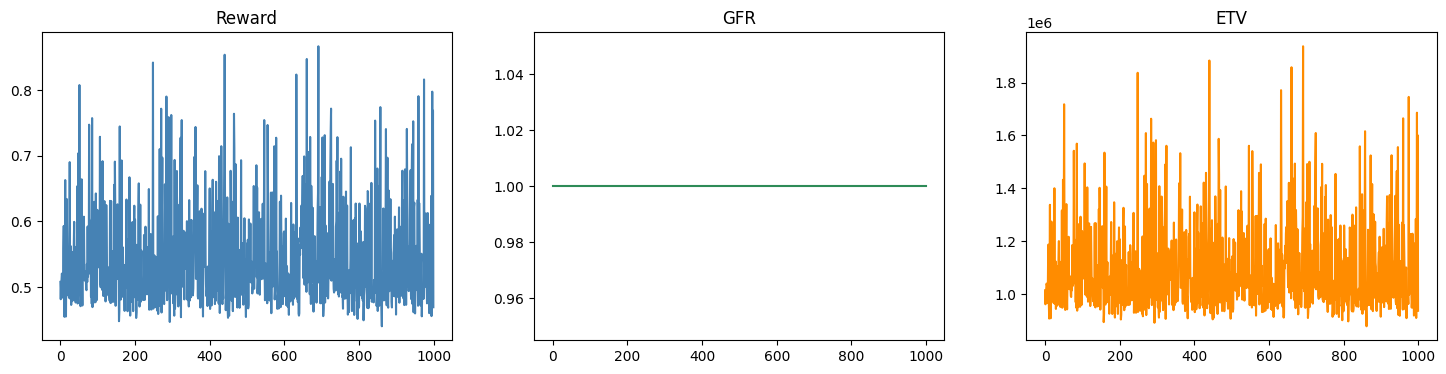

In [ ]:
# ── Reward Convergence Plot ──
if 'history' in locals() and history:
    episodes = [h['episode'] for h in history]
    rewards  = [h['reward'] for h in history]
    gfrs     = [h['GFR'] for h in history]
    etvs     = [h['ETV'] for h in history]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    axes[0].plot(episodes, rewards, color='steelblue')
    axes[0].set_title('Reward')
    axes[1].plot(episodes, gfrs, color='seagreen')
    axes[1].set_title('GFR')
    axes[2].plot(episodes, etvs, color='darkorange')
    axes[2].set_title('ETV')
    plt.show()